In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("CHAT Gene - Canine Congenital Myasthenic Syndrome Project")
print("Analysis environment is ready.")

CHAT Gene - Canine Congenital Myasthenic Syndrome Project
Analysis environment is ready.


In [ ]:
# loading EVA variant data
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/chat_CMS/Dog_CanFam3.1_Variants.csv"
variants = pd.read_csv(file_path)

print("Total number of variants:", len(variants))
print("\nVariant consequence distribution:")
print(variants['consequenceTypes'].value_counts())

print("\nDataset preview:")
display(variants)

Mounted at /content/drive
Total number of variants: 10

Variant consequence distribution:
consequenceTypes
intron_variant        8
synonymous_variant    1
missense_variant      1
Name: count, dtype: int64

Dataset preview:


,chromosome,start,end,reference,alternate,type,consequenceTypes,ids,Organism / Assembly,Unnamed: 9
0,28,1484238,1484238,C,A,SNV,intron_variant,-,Dog/CanFam3.1,NaN
1,28,1484353,1484353,C,T,SNV,intron_variant,-,Dog/CanFam3.1,NaN
2,28,1484365,1484365,C,A,SNV,intron_variant,-,Dog/CanFam3.1,NaN
3,28,1484569,1484569,G,C,SNV,intron_variant,-,Dog/CanFam3.1,NaN
4,28,1484732,1484732,C,G,SNV,intron_variant,-,Dog/CanFam3.1,NaN
5,28,1484734,1484734,C,T,SNV,intron_variant,-,Dog/CanFam3.1,NaN
6,28,1484745,1484745,C,T,SNV,intron_variant,-,Dog/CanFam3.1,NaN
7,28,1484746,1484746,G,A,SNV,intron_variant,-,Dog/CanFam3.1,NaN
8,28,1484965,1484965,T,C,SNV,synonymous_variant,-,Dog/CanFam3.1,NaN
9,28,1485045,1485045,A,G,SNV,missense_variant,-,Dog/CanFam3.1,NaN


In [ ]:
# select protein-changing missense variants

missense_variants = variants[
    variants["consequenceTypes"] == "missense_variant"
].copy()

print("Number of missense variants:", len(missense_variants))
display(missense_variants)

Number of missense variants: 1


,chromosome,start,end,reference,alternate,type,consequenceTypes,ids,Organism / Assembly,Unnamed: 9
9,28,1485045,1485045,A,G,SNV,missense_variant,-,Dog/CanFam3.1,NaN


In [ ]:
# candidate missense variant identified from EVA

candidate_variant = {
    "chromosome": 28,
    "position": 1485045,
    "reference": "A",
    "alternate": "G",
    "assembly": "CanFam3.1"
}

candidate_variant

{'chromosome': 28,
 'position': 1485045,
 'reference': 'A',
 'alternate': 'G',
 'assembly': 'CanFam3.1'}

In [ ]:
# building a comparison table with the known disease associated variant and the candidate misssense variant identified from EVA

comparison_data = pd.DataFrame([
    {
        "variant_role": "Known disease-associated variant",
        "chromosome": 28,
        "position": 1484906,
        "reference": "G",
        "alternate": "A",
        "protein_change": "p.V29M",
        "source": "OMIA / Proschowsky et al. 2007"
    },
    {
        "variant_role": "Candidate variant",
        "chromosome": 28,
        "position": 1485045,
        "reference": "A",
        "alternate": "G",
        "protein_change": "p.K75R",
        "source": "EVA"
    }
])

display(comparison_data)

,variant_role,chromosome,position,reference,alternate,protein_change,source
0,Known disease-associated variant,28,1484906,G,A,p.V29M,OMIA / Proschowsky et al. 2007
1,Candidate variant,28,1485045,A,G,p.K75R,EVA


In [ ]:
# compare amino acid substitutions using BLOSUM62 and Grantham distance

substitution_data = pd.DataFrame([
    {
        "variant": "p.V29M",
        "original_aa": "V",
        "new_aa": "M",
        "BLOSUM62_score": 1,
        "Grantham_distance": 21
    },
    {
        "variant": "p.K75R",
        "original_aa": "K",
        "new_aa": "R",
        "BLOSUM62_score": 2,
        "Grantham_distance": 26
    }
])

display(substitution_data)

,variant,original_aa,new_aa,BLOSUM62_score,Grantham_distance
0,p.V29M,V,M,1,21
1,p.K75R,K,R,2,26


In [ ]:
# Simple interpretation of amino acid substitutions

def interpret_grantham(distance):
    if distance < 50:
        return "Conservative"
    elif distance < 100:
        return "Moderately conservative"
    elif distance < 150:
        return "Moderately radical"
    else:
        return "Radical"

substitution_data["substitution_type"] = substitution_data[
    "Grantham_distance"
].apply(interpret_grantham)

display(substitution_data)

,variant,original_aa,new_aa,BLOSUM62_score,Grantham_distance,substitution_type
0,p.V29M,V,M,1,21,Conservative
1,p.K75R,K,R,2,26,Conservative


In [ ]:
# physicalchemically both are conservative meaning not much of a change. protein's location and function is more important.

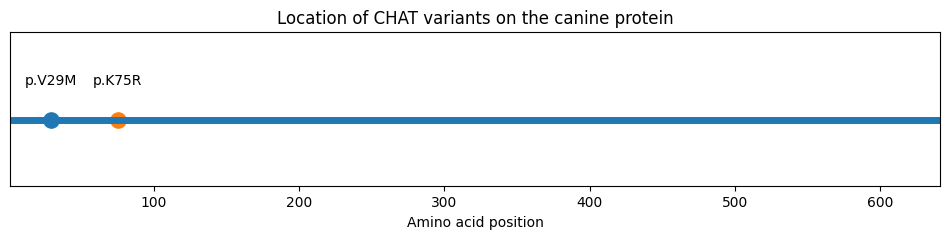

In [ ]:
# visualize the positions of the known disease-associated
# and candidate variants on the CHAT protein

protein_length = 641

variant_positions = pd.DataFrame([
    {
        "variant": "p.V29M",
        "position": 29,
        "role": "Known disease-associated variant"
    },
    {
        "variant": "p.K75R",
        "position": 75,
        "role": "Candidate variant"
    }
])

plt.figure(figsize=(12,2))
#drawing the protein backbone
plt.hlines(
    y=1,
    xmin=1,
    xmax=protein_length,
    linewidth=5
)
#plot variant position
for _, row in variant_positions.iterrows():
  plt.scatter(row["position"], 1, s=120)
  plt.text(
      row["position"],
      1.08,
      row["variant"],
      ha="center",
      fontsize=10
  )

plt.xlim(1, protein_length)
plt.ylim(0.85, 1.2)

plt.xlabel("Amino acid position")
plt.title("Location of CHAT variants on the canine protein")

plt.yticks([])
plt.show()

In [ ]:
# iki varyantta 641 aminoasitlik CHAT proteinin N terminal tarafında bulunuyor.

In [ ]:
#calculate relative position of each variant along the protein

variant_positions["relative_position_percent"] = (
    variant_positions["position"] / protein_length * 100
)
display(variant_positions)


,variant,position,role,relative_position_percent
0,p.V29M,29,Known disease-associated variant,4.524181
1,p.K75R,75,Candidate variant,11.700468


In [ ]:
#Canine CHAT protein sequence
#RefSeq protein: XP_005637542.1
chat_protein = (
    "MPILEKAPHKTATKTPSSEEEPKLPKLPVPPLQQTLATYLRCMQHLVPEE"
    "QFRRSQAIVQQFGAPGGLGETLQQKLLERQEKTANWVSEYWLNDMYLNNR"
    "LALPVNSSPAVIFARQHFQDTSDQLRFAASLISGVLHYKTMLDSHSIPPD"
    "CAKGQLSGQPLCMKQYYGLFSSYRLPGHTQDTLVAQKSSVMPEPEHIIVA"
    "CCNQFFVLDVVINFRRLSEGDLFTQLRKIVKMASNEDERLPPIGLLTSEG"
    "RSEWAEARTVLVKDSTNRDALDMIERCICLVCLDAPGGVDLNDTNRALQL"
    "LHGGGCSKNGANRWYDKSLQFVVGRDGTCGVVCEHSPFDGIVLVQCTEHL"
    "LKHMVKSGKKLVRADSVSELPAPRRLRWKCSPEIQGLLASSAEKLQRIVK"
    "NLDFTVYKFDIFGKTFIKKQKCSPDAFIQVALQLAFYRLHRRLVPTYESA"
    "SIRRFQEGRVDNIRSATPEALSFVKAITDHKAAVPDSEKLQLLKDAIRAQ"
    "TEYTVMAITGMAIDNHLLALRELARDTCKELPEMFTDETYLMSNRFILST"
    "SQVPTTMEMFCCYGPVVPNGYGACYNPQPESILFCISSFHGCKDTSSTKF"
    "AKAVEESLIEMRDLCSLPQSTVGKPLATKEKATRPIQGHQP"
)
print("protein length:", len(chat_protein))

protein length: 641


In [ ]:
#extract local amino acid sequence around each variant

def get_sequence_window(sequence, position, window=10):
  start = max(0, position - window - 1)
  end = min(len(sequence), position + window)
  local_sequence = sequence[start:end]
  return {
      "position": position,
      "amino_acid": sequence[position - 1],
      "sequence_window": local_sequence
  }
v29_context = get_sequence_window(chat_protein, 29)
k75_context = get_sequence_window(chat_protein, 75)

print("p.V29M context:")
print(v29_context)
print("\np.K75R context:")
print(k75_context)

p.V29M context:
{'position': 29, 'amino_acid': 'V', 'sequence_window': 'EEEPKLPKLPVPPLQQTLATY'}

p.K75R context:
{'position': 75, 'amino_acid': 'K', 'sequence_window': 'PGGLGETLQQKLLERQEKTAN'}


In [ ]:
# Display local sequence context with the variant residue highlighted

def highlight_variant(sequence, position, window=10):
    start = max(0, position - window - 1)
    end = min(len(sequence), position + window)

    local_sequence = sequence[start:end]

    local_index = position - start - 1

    highlighted = (
        local_sequence[:local_index]
        + "["
        + local_sequence[local_index]
        + "]"
        + local_sequence[local_index + 1:]
    )

    return highlighted


print("Known disease-associated variant:")
print("p.V29M :", highlight_variant(chat_protein, 29))

print("\nCandidate variant:")
print("p.K75R :", highlight_variant(chat_protein, 75))

Known disease-associated variant:
p.V29M : EEEPKLPKLP[V]PPLQQTLATY

Candidate variant:
p.K75R : PGGLGETLQQ[K]LLERQEKTAN


In [ ]:
# Assign analysis priority to all identified SNVs

def assign_priority(consequence):
    if consequence == "missense_variant":
        return "Primary candidate"
    elif consequence == "synonymous_variant":
        return "Secondary candidate"
    elif consequence == "intron_variant":
        return "Secondary candidate"
    else:
        return "Other"

variants["analysis_priority"] = variants["consequenceTypes"].apply(assign_priority)

display(variants)

# Summarize analysis priorities

print("Analysis priority distribution:")
print(variants["analysis_priority"].value_counts())

,chromosome,start,end,reference,alternate,type,consequenceTypes,ids,Organism / Assembly,Unnamed: 9,analysis_priority
0,28,1484238,1484238,C,A,SNV,intron_variant,-,Dog/CanFam3.1,NaN,Secondary candidate
1,28,1484353,1484353,C,T,SNV,intron_variant,-,Dog/CanFam3.1,NaN,Secondary candidate
2,28,1484365,1484365,C,A,SNV,intron_variant,-,Dog/CanFam3.1,NaN,Secondary candidate
3,28,1484569,1484569,G,C,SNV,intron_variant,-,Dog/CanFam3.1,NaN,Secondary candidate
4,28,1484732,1484732,C,G,SNV,intron_variant,-,Dog/CanFam3.1,NaN,Secondary candidate
5,28,1484734,1484734,C,T,SNV,intron_variant,-,Dog/CanFam3.1,NaN,Secondary candidate
6,28,1484745,1484745,C,T,SNV,intron_variant,-,Dog/CanFam3.1,NaN,Secondary candidate
7,28,1484746,1484746,G,A,SNV,intron_variant,-,Dog/CanFam3.1,NaN,Secondary candidate
8,28,1484965,1484965,T,C,SNV,synonymous_variant,-,Dog/CanFam3.1,NaN,Secondary candidate
9,28,1485045,1485045,A,G,SNV,missense_variant,-,Dog/CanFam3.1,NaN,Primary candidate


Analysis priority distribution:
analysis_priority
Secondary candidate    9
Primary candidate      1
Name: count, dtype: int64


şimdi ise intronik snv lerde exon-introm sınırına ne kadar yakın oldugu hesaplanıp splice bölgesine yakın olan intron varyantları analiz edilcek.

In [ ]:
# CHAT transcript exon coordinates
# RefSeq transcript: XM_005637485.3
# UCSC canFam3 / CanFam3.1

exon_starts_0based = [
    1480363, 1482678, 1484887, 1485848, 1487336,
    1488908, 1491100, 1510243, 1512972, 1513967,
    1516536, 1519593, 1519881, 1526623, 1528506
]

exon_ends = [
    1480561, 1482781, 1485079, 1485967, 1487390,
    1489089, 1491278, 1510413, 1513073, 1514096,
    1516659, 1519735, 1519944, 1526761, 1528858
]

# Convert UCSC 0-based exon starts to 1-based genomic coordinates
exon_starts = [x + 1 for x in exon_starts_0based]

exons = pd.DataFrame({
    "exon_number": range(1,16),
    "start": exon_starts,
    "end": exon_ends
})

display(exons)

,exon_number,start,end
0,1,1480364,1480561
1,2,1482679,1482781
2,3,1484888,1485079
3,4,1485849,1485967
4,5,1487337,1487390
5,6,1488909,1489089
6,7,1491101,1491278
7,8,1510244,1510413
8,9,1512973,1513073
9,10,1513968,1514096


In [ ]:
# Determine exon location and distance to the nearest exon boundary

def analyze_exon_location(position):

    # Check whether the variant is located inside an exon
    for exon_number, start, end in zip(
        exons["exon_number"],
        exons["start"],
        exons["end"]
    ):
        if start <= position <= end:

            distance_to_start = position - start
            distance_to_end = end - position

            return pd.Series([
                f"Exon {exon_number}",
                min(distance_to_start, distance_to_end)
            ])

    # If not exonic, calculate distance to nearest exon boundary
    boundaries = list(exons["start"]) + list(exons["end"])

    nearest_boundary = min(
        boundaries,
        key=lambda x: abs(position - x)
    )

    return pd.Series([
        "Intron",
        abs(position - nearest_boundary)
    ])


variants[
    ["transcript_location", "distance_to_exon_boundary_bp"]
] = variants["start"].apply(analyze_exon_location)

display(
    variants[
        [
            "start",
            "reference",
            "alternate",
            "consequenceTypes",
            "transcript_location",
            "distance_to_exon_boundary_bp"
        ]
    ]
)

,start,reference,alternate,consequenceTypes,transcript_location,distance_to_exon_boundary_bp
0,1484238,C,A,intron_variant,Intron,650
1,1484353,C,T,intron_variant,Intron,535
2,1484365,C,A,intron_variant,Intron,523
3,1484569,G,C,intron_variant,Intron,319
4,1484732,C,G,intron_variant,Intron,156
5,1484734,C,T,intron_variant,Intron,154
6,1484745,C,T,intron_variant,Intron,143
7,1484746,G,A,intron_variant,Intron,142
8,1484965,T,C,synonymous_variant,Exon 3,77
9,1485045,A,G,missense_variant,Exon 3,34


introonic snv lerin hiçbirinde 1-2 baz splicesiteda görünmüyorlar en yakını bile 142 bp uzaklıkta yani hiç biri bizim için güçlü adaylar değil!

ek olarakta missense ve synonmous varyant exon 3 içinde!!

In [ ]:
# building an integrated prioritization table fo all 10 SNVs

def classify_splice_relevance(row):
  if row["transcript_location"].startswith("Exon"):
    return "Exonic"
  distance = row["distance_to_exon_boundary_bp"]
  if distance <= 2:
    return "Canonical splice-site"
  elif distance <= 20:
    return "Near splice-site"
  else:
    return "Low splice-site proximity"

def assign_overall_priority(row):
  consequence = row["consequenceTypes"]
  if consequence == "missense_variant":
    return "High"
  elif consequence == "synonymous_variant":
    return "Medium"
  elif (consequence == "intron_variant" and row["distance_to_exon_boundary_bp"] <= 20):
    return "Medium"
  else:
    return "Low"


variants["splice_relevance"] = variants.apply(
    classify_splice_relevance,
    axis=1
)

variants["overall_priority"] = variants.apply(
    assign_overall_priority,
    axis=1
)

priority_table = variants[
    [
        "chromosome",
        "start",
        "reference",
        "alternate",
        "consequenceTypes",
        "transcript_location",
        "distance_to_exon_boundary_bp",
        "splice_relevance",
        "overall_priority"
    ]
].copy()

display(priority_table)

,chromosome,start,reference,alternate,consequenceTypes,transcript_location,distance_to_exon_boundary_bp,splice_relevance,overall_priority
0,28,1484238,C,A,intron_variant,Intron,650,Low splice-site proximity,Low
1,28,1484353,C,T,intron_variant,Intron,535,Low splice-site proximity,Low
2,28,1484365,C,A,intron_variant,Intron,523,Low splice-site proximity,Low
3,28,1484569,G,C,intron_variant,Intron,319,Low splice-site proximity,Low
4,28,1484732,C,G,intron_variant,Intron,156,Low splice-site proximity,Low
5,28,1484734,C,T,intron_variant,Intron,154,Low splice-site proximity,Low
6,28,1484745,C,T,intron_variant,Intron,143,Low splice-site proximity,Low
7,28,1484746,G,A,intron_variant,Intron,142,Low splice-site proximity,Low
8,28,1484965,T,C,synonymous_variant,Exon 3,77,Exonic,Medium
9,28,1485045,A,G,missense_variant,Exon 3,34,Exonic,High
